In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch_geometric

import sys
sys.path.append('./..')
    
from ld_gcn import network, loader, plotting, preprocessing, testing, error, training, utils, interpolation, initialization
from IPython.display import HTML

import numpy as np

# Define PDE problem

In [2]:
pde_problem = 12
problem_name, variable, mu_space, n_param, dim_pde, n_comp, n_sim, HyperParams = utils.prepare_HyperParams(pde_problem)

Problem: square_advection
Variable: U
Parameters: 2


# Initialize device and set reproducibility

In [3]:
device = initialization.initialize(HyperParams)

Device used:  cuda


# Load dataset

In [4]:
dataset_dir = '../dataset/'+problem_name+'_unstructured.mat'
dataset = loader.LoadDataset(dataset_dir, variable, dim_pde, n_comp)

In [5]:
n_snap2keep = int(dataset.U.shape[1]/(len(mu_space[0])*len(mu_space[1])))
delete_first_n = 1

dataset, mu_space = preprocessing.delete_initial_condition(dataset, mu_space, n_comp, n_snap2keep, n_delete=delete_first_n)

params = utils.create_param_list(mu_space, device)

In [6]:
graph_loader, train_loader, test_loader, \
    val_loader, scaler_all, scaler_test, xyz, VAR_all, VAR_val, VAR_test, \
        train_trajectories, val_trajectories, test_trajectories, params_train, params_test = preprocessing.graphs_dataset(dataset, HyperParams, params)

Number of nodes processed:  1472
Number of graphs processed:  2500
Length of train dataset:  1350
Length of test dataset:  700


# Define the architecture

In [7]:
RecNet = network.RecNet(HyperParams)
RecNet = RecNet.to(device)
DynNet = network.DynNet(HyperParams)
DynNet = DynNet.to(device)

torch.set_default_dtype(torch.float32)

optimizer = 'ADAM' # 'ADAM' or 'LBFGS'

if optimizer == 'ADAM':
    optimizer = torch.optim.Adam([
        {'params': DynNet.parameters()},
        {'params': RecNet.parameters()}
      ],
      lr=HyperParams.learning_rate,
      weight_decay=HyperParams.weight_decay
    )

elif optimizer == 'LBFGS':
    optimizer = torch.optim.LBFGS(
        list(DynNet.parameters())+list(RecNet.parameters()),
        lr = 1.,
        max_iter = HyperParams.max_epochs,
        max_eval = None,
        tolerance_grad = 1e-07,
        tolerance_change = 1e-09,
        history_size = 30,
        line_search_fn = 'strong_wolfe',
    )

scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=HyperParams.miles, gamma=HyperParams.gamma)

In [8]:
compile = False

if compile:
    try:
        import torch._dynamo
        torch._dynamo.config.suppress_errors = True
        RecNet = torch.compile(RecNet)
        DynNet = torch.compile(DynNet)
        print('The networks have been compiled successfully')
    except:
        print('Not possible to compile the networks')

In [9]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters in dynnet:", count_trainable_params(DynNet))
print("Trainable parameters in recnet:", count_trainable_params(RecNet))

Trainable parameters in dynnet: 24813
Trainable parameters in recnet: 297289


# Train or load a pre-trained network

In [10]:
# To reduce memory consumption on GPU:
params = params.to("cpu")
VAR_all = VAR_all.to("cpu")
VAR_val = VAR_val.to("cpu")
VAR_test = VAR_test.to("cpu")
if device=='cuda':
    torch.cuda.empty_cache()

In [11]:
load = True
train = False

if load:
    try:
        RecNet.load_state_dict(torch.load(HyperParams.net_dir+HyperParams.net_name+HyperParams.net_run+'_decoder.pt', map_location=torch.device('cpu')))
        DynNet.load_state_dict(torch.load(HyperParams.net_dir+HyperParams.net_name+HyperParams.net_run+'_dyn.pt', map_location=torch.device('cpu')))
        print('Loading saved network')
    except FileNotFoundError:
        print('Not possible to load the network')
        train = True

if train:
    training.train(RecNet, DynNet, optimizer, device, scheduler, train_loader, test_loader, HyperParams, params_train, params_test)

Loading saved network


# Evaluate the model

In [12]:
RecNet = RecNet.to("cpu")
DynNet = DynNet.to("cpu")

vars = "GCA-ROM"
VAR_train = VAR_all[train_trajectories,:,:]

In [13]:
results, latents = testing.evaluate(VAR_all, RecNet, DynNet, graph_loader, params, HyperParams)
results_test, latents_test = testing.evaluate(VAR_test, RecNet, DynNet, test_loader, params_test, HyperParams)
results_train, latents_ = testing.evaluate(VAR_train, RecNet, DynNet, train_loader, params_train, HyperParams)
results_val = results[val_trajectories,:,:]

Evaluating the model...
Evaluation complete!
Evaluating the model...
Evaluation complete!
Evaluating the model...
Evaluation complete!


# Compute the errors

In [14]:
vars = problem_name

error_abs, norm = error.compute_error(results, VAR_all, scaler_all)
error_abs_test, norm_test = error.compute_error(results_test, VAR_test, scaler_all)
error_abs_train, norm_train = error.compute_error(results_train, VAR_train, scaler_all)
error_abs_val, norm_val = error.compute_error(results_val, VAR_val, scaler_all)

print('\nERRORS ON THE TRAINING SET:')
error.print_error(error_abs_train, norm_train, vars)
print('\nERRORS ON THE TEST SET:')
error.print_error(error_abs_test, norm_test, vars)
print('\nERRORS ON THE VALIDATION DATASET:')
error.print_error(error_abs_val, norm_val, vars)
print('\nERRORS ON THE WHOLE DATASET:')
error.print_error(error_abs, norm, vars)

error.save_error(error_abs_test, norm_test, HyperParams, vars)


ERRORS ON THE TRAINING SET:

Maximum absolute error for field square_advection =  0.16397369
Mean absolute error for field square_advection =  0.03972321525216103
Minimum absolute error for field square_advection =  0.01308643

Maximum relative error for field square_advection =  0.0052540074
Mean relative error for field square_advection =  0.0011814176308042887
Minimum relative error for field square_advection =  0.00037809456

ERRORS ON THE TEST SET:

Maximum absolute error for field square_advection =  2.138473
Mean absolute error for field square_advection =  0.2748322309553623
Minimum absolute error for field square_advection =  0.02307473

Maximum relative error for field square_advection =  0.052603416
Mean relative error for field square_advection =  0.007856598331293624
Minimum relative error for field square_advection =  0.0006469991

ERRORS ON THE VALIDATION DATASET:

Maximum absolute error for field square_advection =  3.239872
Mean absolute error for field square_advecti

In [15]:
n_snapshots = n_snap2keep - delete_first_n

max_error_index = np.argmax(np.array(error_abs)/np.array(norm))
print(f'Index of the max of the relative error: {max_error_index}')
print(f'Indices of test trajectories: {(np.array(test_trajectories)/(n_snapshots))[::n_snapshots]}')

Index of the max of the relative error: 2499
Indices of test trajectories: [ 1. 10. 12. 15. 17. 18. 20.]


# Plot the results

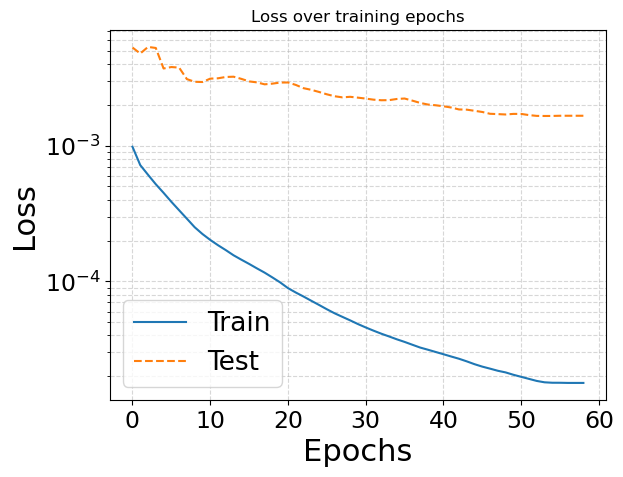

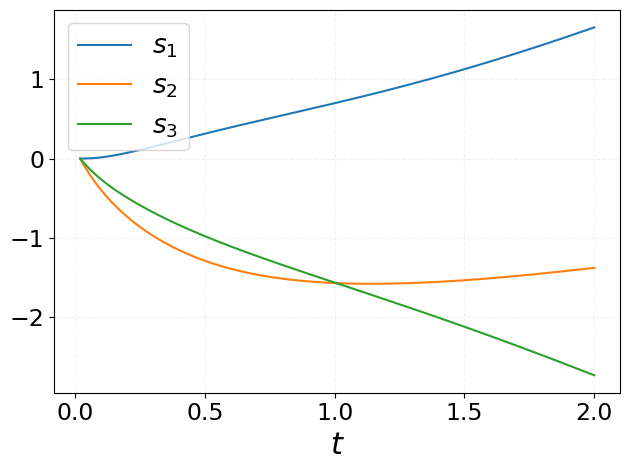

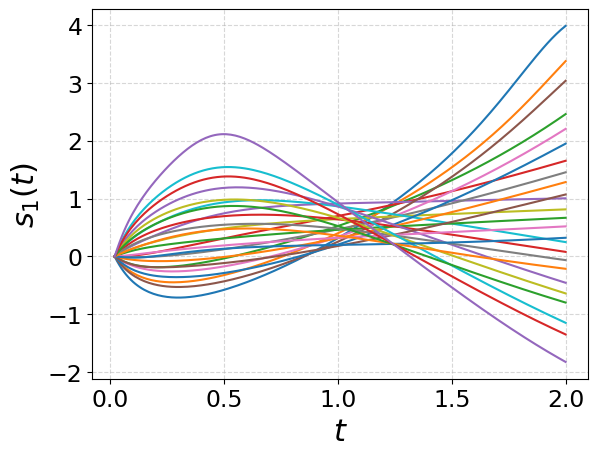

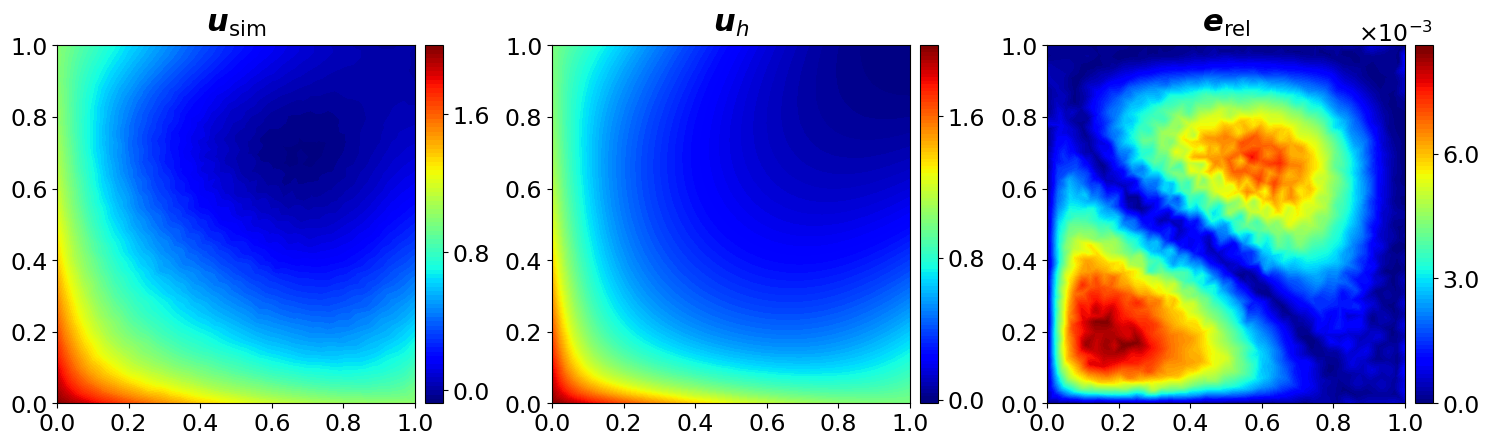

In [16]:
plotting.plot_loss(HyperParams)

SAMPLE = 3
plotting.plot_latent_time(HyperParams, SAMPLE, latents, params, n_sim)

component = 0
plotting.plot_latent_component(HyperParams, component, latents, params, n_sim)

total_times = n_snap2keep - delete_first_n
SAMPLE = max_error_index//total_times # index of the parameter for which we want to plot, in the case the one with the greatest error
SNAP = max_error_index - SAMPLE*total_times #SNAP represents the i-th snapshot in the time evolution

plotting.plot_fields(SAMPLE, SNAP, results, scaler_all, HyperParams, dataset, params)

In [17]:
final_time = params_train[..., -1][0][-1].to(device='cpu')
rel_errors = np.array(error_abs)/np.array(norm)
rel_errors_test = np.array(error_abs_test)/np.array(norm_test)

#plotting.plot_relative_errors_vs_time(rel_errors, params, HyperParams, final_time, flag='all')
#plotting.plot_relative_errors_vs_time(rel_errors_test, params_test, HyperParams, final_time, flag='test')

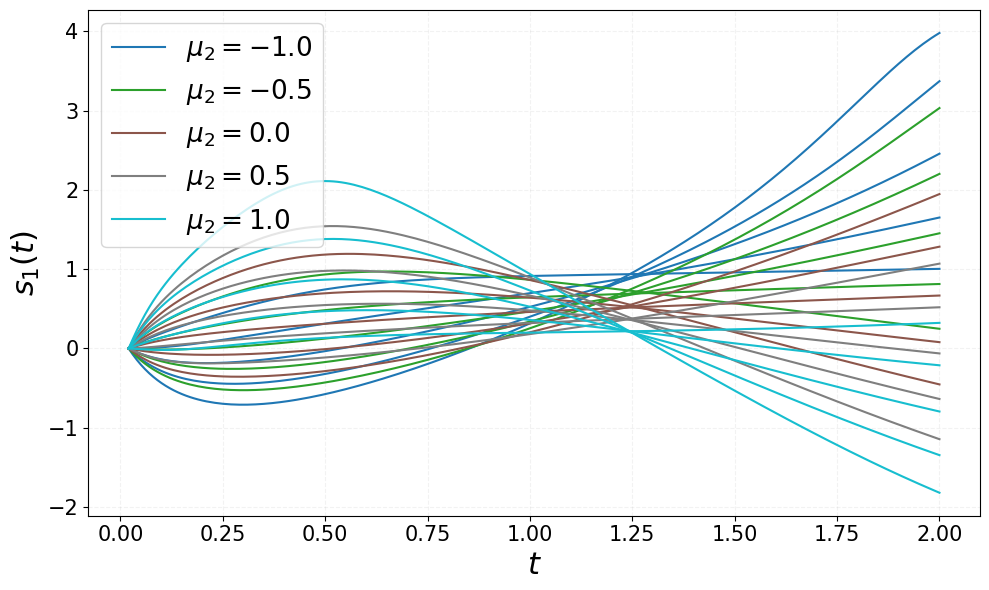

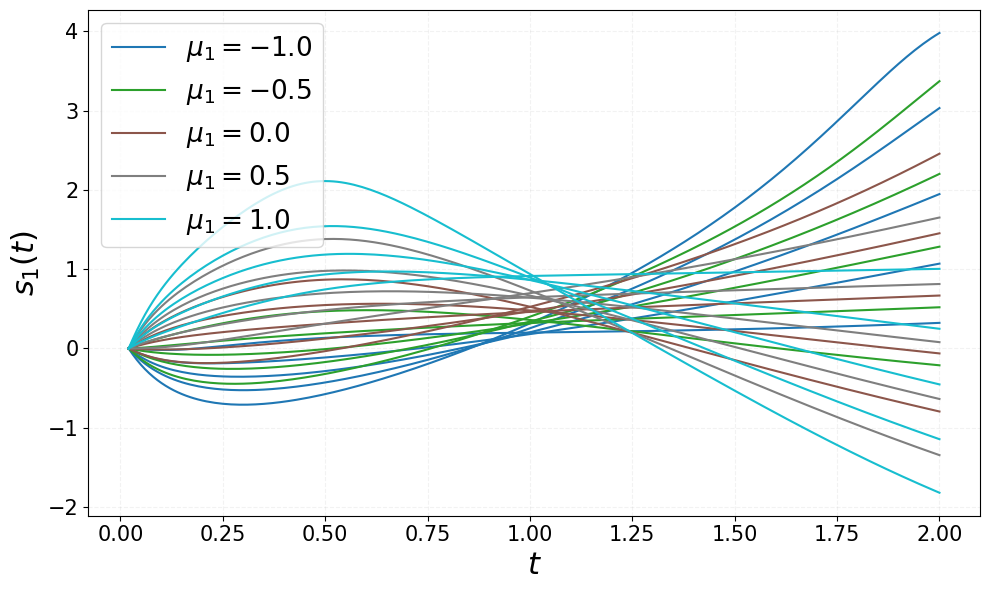

In [18]:
component = 0 # 8 is nice if n=15
plotting.plot_latent_by_mu_group(HyperParams, component, latents, params, n_sim, mu_index=0)
plotting.plot_latent_by_mu_group(HyperParams, component, latents, params, n_sim, mu_index=1)

plot_all = False

if plot_all:
    for i in range(5):
        for j in range(2):
            plotting.plot_latent_by_mu_group(HyperParams, component, latents, params, n_sim, mu_index=j, single_mu_index=i)

In [19]:
n_times_fine = int(latents.shape[0]/n_sim)
params_np = params.detach().cpu().numpy()
latents_np = latents.detach().cpu().numpy()

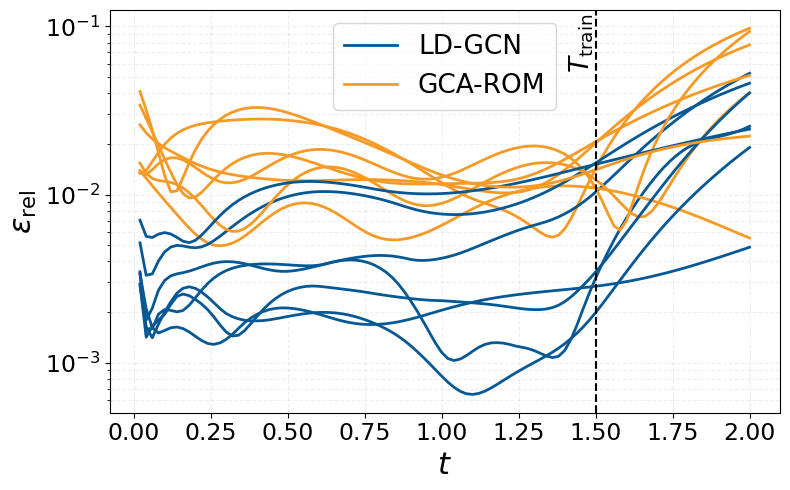

In [20]:
has_errors = True
if has_errors:
    errors_gca = np.load('../gca_data/errors_gca_SA.npy')
    norms_gca = norm_test #np.load('../gca_data/norms_gca_SA.npy')
    rel_errors_gca = errors_gca/norms_gca
    plotting.compare_errors_gca(rel_errors_test, rel_errors_gca, params_test, HyperParams, final_time)

In [21]:
# has_fields = True if HyperParams.bottleneck_dim == 3 else False
# #if not isinstance(Z, np.ndarray):
# #    Z = Z.detach().numpy()

# if has_fields:
#     gca_fields = np.load(f'../gca_data/scaled_output_SA_3.npy') # to be changed
#     Z = preprocessing.inverse_normalize_input(results.detach()[:,:,0].T, scaler_all)
#     Z = Z.numpy() # same shape as gca_fields: n:nodes,n_snaps

#     FO_fields = preprocessing.inverse_normalize_input(VAR_all[:,:,0].T, scaler_all)
#     FO_fields = FO_fields.numpy() # same shape as gca_fields

#     SAMPLE = 10
#     print('Plotting the first field...')
#     plotting.create_animation(SAMPLE, Z, HyperParams, dataset, xyz, n_sim, comp="_U", flag='sim')
#     print('Plotting the second field...')
#     plotting.create_animation(SAMPLE, gca_fields, HyperParams, dataset, xyz, n_sim, comp="_U", flag='gca')
#     print('Plotting the third field...')
#     plotting.create_animation(SAMPLE, FO_fields, HyperParams, dataset, xyz, n_sim, comp="_U", flag='h')

In [22]:
# plotting.animate_latent_evolution(latents_np, params_np, component, n_sim, n_times_fine, HyperParams, three_d=True)

# Test interpolation in the latent space

In [23]:
interpolation_type = 'spline' # 'GPR' or 'spline', this is the one for which we reconstruct the FO trajectories
n_times_coarse = n_snapshots
#### Extrapolation
extrapolate_with_interpolation = False
params_train = params_train.to('cpu')
T_train_fine = params_train.detach().numpy().shape[1]*2-1 if extrapolate_with_interpolation else None

n_train_sim = int(params.shape[0]- params_test.shape[0])
times = params[...,-1].detach().cpu().numpy()[0] # params has shape (n_params, n_times, n_comp)
latent_dim = HyperParams.bottleneck_dim

test_trajectories_indices = (np.array(test_trajectories[::total_times])//total_times).astype(int) # just indices of the test trajectories,
                                                                                                  # not of each snapshot
all_indices = np.arange(params.shape[0])
training_indices = np.setdiff1d(all_indices, test_trajectories_indices) # train on test + validation (or just the first part of test)

latents_train_interpolation = interpolation.prepare_latents_for_interpolation(latents, n_sim, n_times_fine, training_indices, T_train_fine)
latents_complete_interpolation = interpolation.prepare_latents_for_interpolation(latents, n_sim, n_times_fine, all_indices)

indices_for_buiding_train = range(params_train.shape[0]) if extrapolate_with_interpolation else training_indices
params_build = params if not extrapolate_with_interpolation else params_train

times_train = times[:params_train.shape[1]] if extrapolate_with_interpolation else times

coords_train, latent_values_train, times_fine = interpolation.build_coords_and_vals(latents_train_interpolation, params_build, times_train, indices_for_buiding_train)
coords_test, latent_values_test, _ = interpolation.build_coords_and_vals(latents_complete_interpolation, params, times, all_indices)

gpr_interpolators = [] # one for each latent space
spline_interpolators = []
#interpolation.create_interpolators(interpolators, coords_train, latent_values_train, latent_dim, n_train_sim, n_times_fine)
t_build_interpolation = T_train_fine if extrapolate_with_interpolation else n_times_fine
interpolation.create_gpr_interpolators(gpr_interpolators, coords_train, latent_values_train, latent_dim, n_train_sim, t_build_interpolation)
interpolation.create_spline_interpolators(spline_interpolators, coords_train, latent_values_train, latent_dim, n_train_sim, t_build_interpolation)

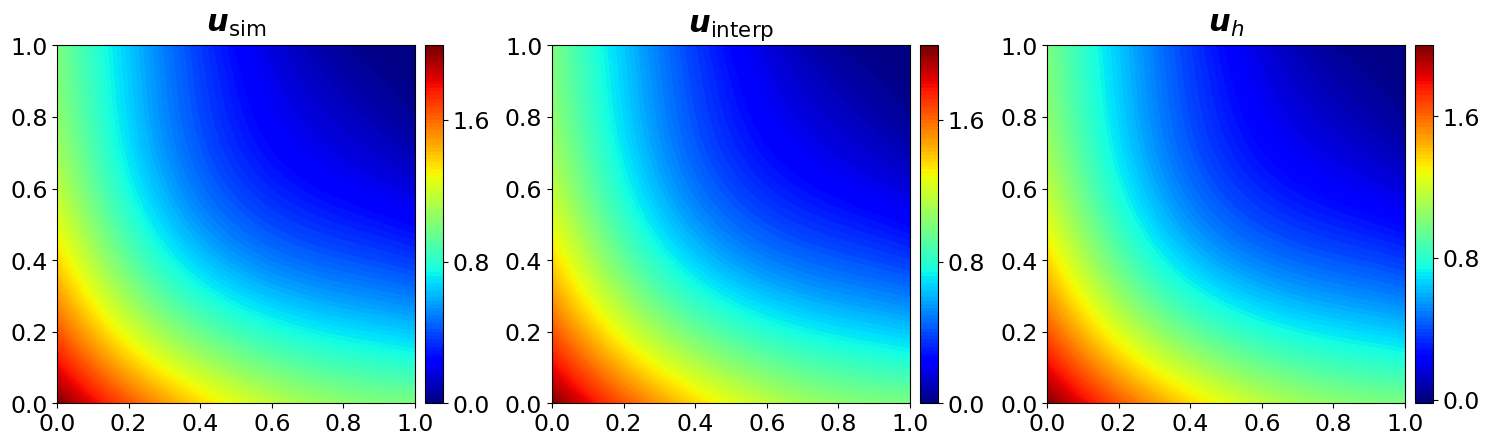

In [24]:
data_list, _, ratio, used_params = utils.prepare_data('cpu', graph_loader, HyperParams, params)

mu1_query_index = 0
mu2_query_index = 1
mu1_query = mu_space[0][mu1_query_index]
mu2_query = mu_space[1][mu2_query_index]
param_index = mu1_query_index * len(mu_space[1]) + mu2_query_index

interpolated_trajectory_gpr = []
interpolated_trajectory_spline = []

interp_errors_gpr = [] # errors of the interpolated traj.s wrt the FO ones
interp_errors_spline = []
sim_errors = [] # same with 
interp_sim_errors_gpr = []
interp_sim_errors_spline = []

plot_index = 48 # time index (of t_coarse) for which we want to plot

for i in range(0, n_times_fine):
    t_query_index = i

    test_index = interpolation.get_index(mu_space, mu1_query_index, mu2_query_index, t_query_index, n_times_fine)
    test_point = coords_test[test_index, :]

    interpolated_latent_state_gpr = None
    interpolated_latent_state_spline = None

    interpolated_latent_state_gpr = interpolation.interpolate_gpr_latents(*test_point, gpr_interpolators)
    interpolated_latent_state_spline = interpolation.interpolate_spline_latents(*test_point, spline_interpolators)
   
    interpolated_trajectory_gpr.append(interpolated_latent_state_gpr)
    interpolated_trajectory_spline.append(interpolated_latent_state_spline)
   
    # real_latent_state = latent_values_test[:, t_query_index, mu1_query_index*len(mu_space[0]) + mu2_query_index]
    # TEST: sanity check
    # assert np.allclose(real_latent_state, interpolated_latent_state)

    actual_time_index = int(t_query_index//ratio)

    if i%ratio == 0:
        index = interpolation.get_index(mu_space, mu1_query_index, mu2_query_index, actual_time_index, n_times_coarse)
        used_data = data_list[index]

        interpolated_latent_state_gpr = interpolated_latent_state_gpr.astype(np.float32)
        interpolated_latent_state_spline = interpolated_latent_state_spline.astype(np.float32)

        interpolated_latent_state_gpr = torch.tensor(interpolated_latent_state_gpr)
        interpolated_latent_state_spline = torch.tensor(interpolated_latent_state_spline)

        interp_solution_gpr = utils.decode(
            RecNet,
            HyperParams,
            interpolated_latent_state_gpr,
            used_params[param_index, t_query_index,:],
            used_data
        )
        interp_solution_spline = utils.decode(
            RecNet,
            HyperParams,
            interpolated_latent_state_spline,
            used_params[param_index, t_query_index,:],
            used_data
        )

        simulated_solution = results[index]
        exact_solution = dataset.U[:,index]

        interp_solution_gpr = utils.renormalize_single_snapshot(scaler_all, interp_solution_gpr)
        interp_solution_spline = utils.renormalize_single_snapshot(scaler_all, interp_solution_spline)
        simulated_solution = utils.renormalize_single_snapshot(scaler_all, simulated_solution)

        interp_errors_gpr.append(utils.relerr(interp_solution_gpr, exact_solution))
        interp_errors_spline.append(utils.relerr(interp_solution_spline, exact_solution))

        sim_errors.append(utils.relerr(simulated_solution, exact_solution))

        interp_sim_errors_gpr.append(torch.norm(interp_solution_gpr-simulated_solution).item()/torch.norm(exact_solution).item())#utils.relerr(interp_solution_gpr, simulated_solution))
        interp_sim_errors_spline.append(torch.norm(interp_solution_spline-simulated_solution).item()/torch.norm(exact_solution).item())#utils.relerr(interp_solution_spline, simulated_solution))

    solution_to_plot = interp_solution_gpr if extrapolate_with_interpolation else interp_solution_spline

    if i//ratio == plot_index:
        plotting.plot_interp_comparison(
            param_index,
            actual_time_index,
            simulated_solution.detach().numpy(),
            solution_to_plot.detach().numpy(),
            HyperParams,
            dataset,
            times,
            extrapolate_with_interpolation
        )
        plot_index-=1 # to avoid plotting twice

interpolated_trajectory_gpr = np.array(interpolated_trajectory_gpr).T
interpolated_trajectory_spline = np.array(interpolated_trajectory_spline).T

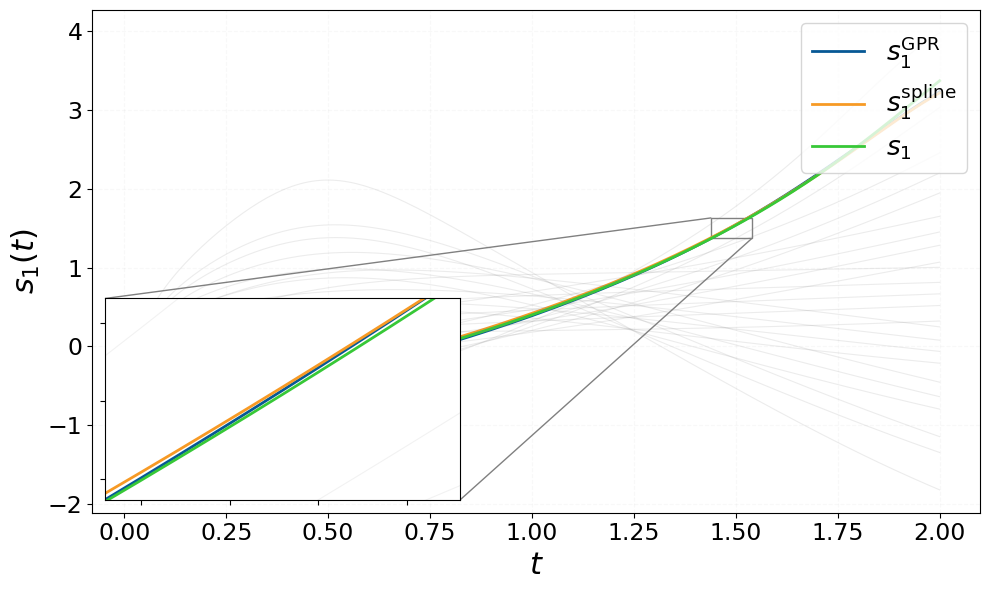

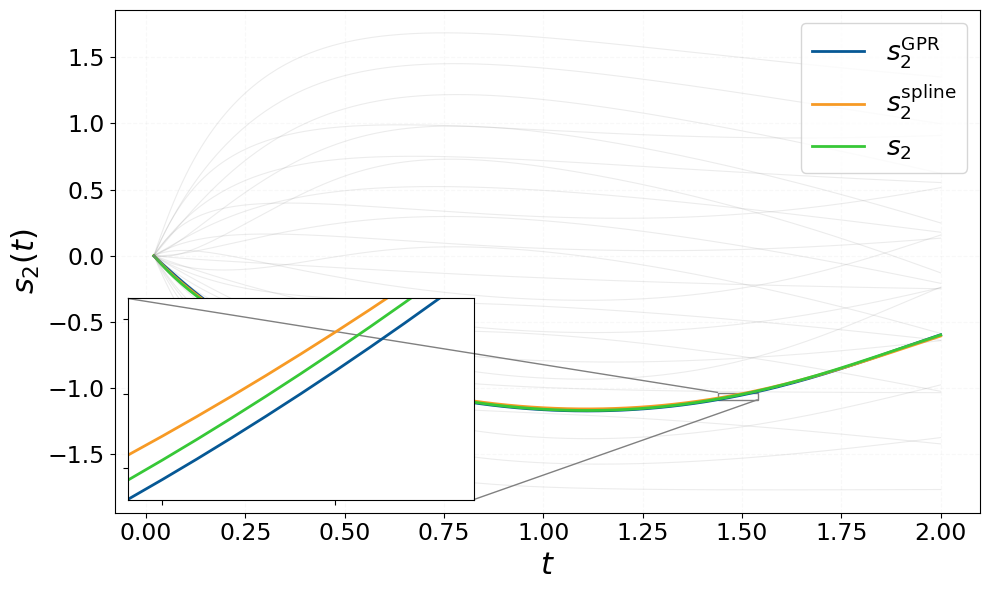

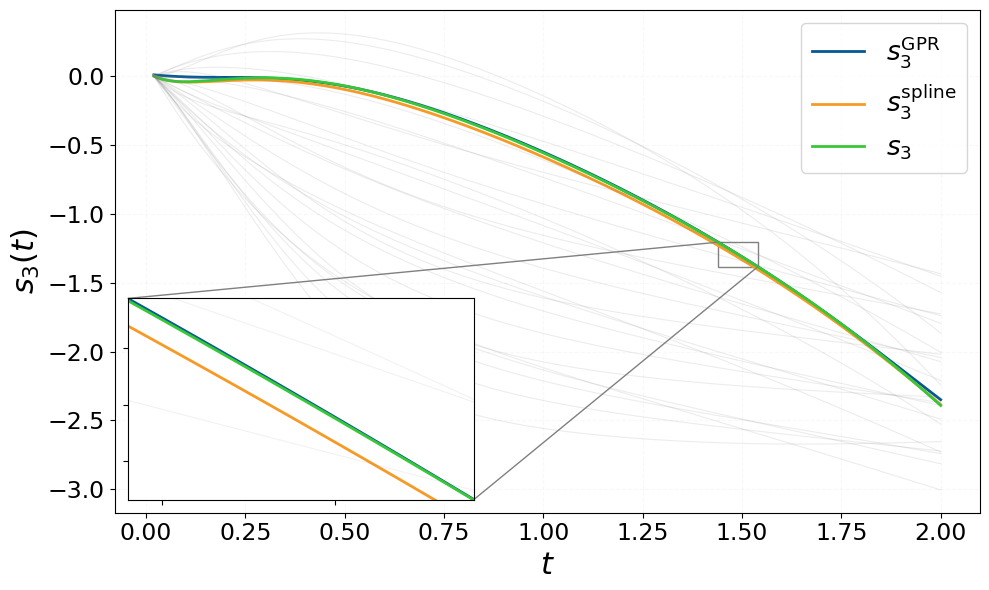

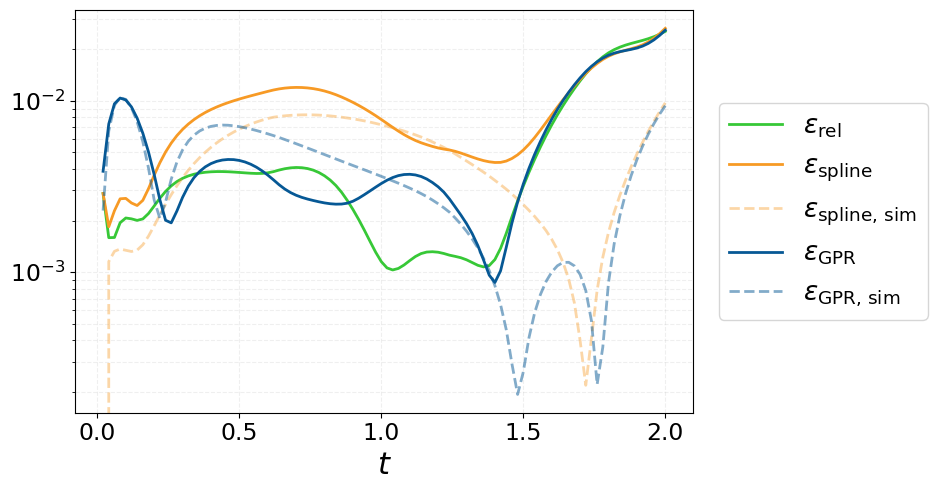

In [25]:
plot_components = True

if plot_components:
    for component in range(latent_dim):
        plotting.plot_interpolated_latent(
            HyperParams,
            component,
            interpolated_trajectory_gpr,
            interpolated_trajectory_spline,
            latent_values_test,
            param_index,
            params,
            True,
        )

plotting.plot_real_interp_error(times, sim_errors, interp_errors_gpr, interp_sim_errors_gpr, HyperParams, interp_errors_spline, interp_sim_errors_spline)

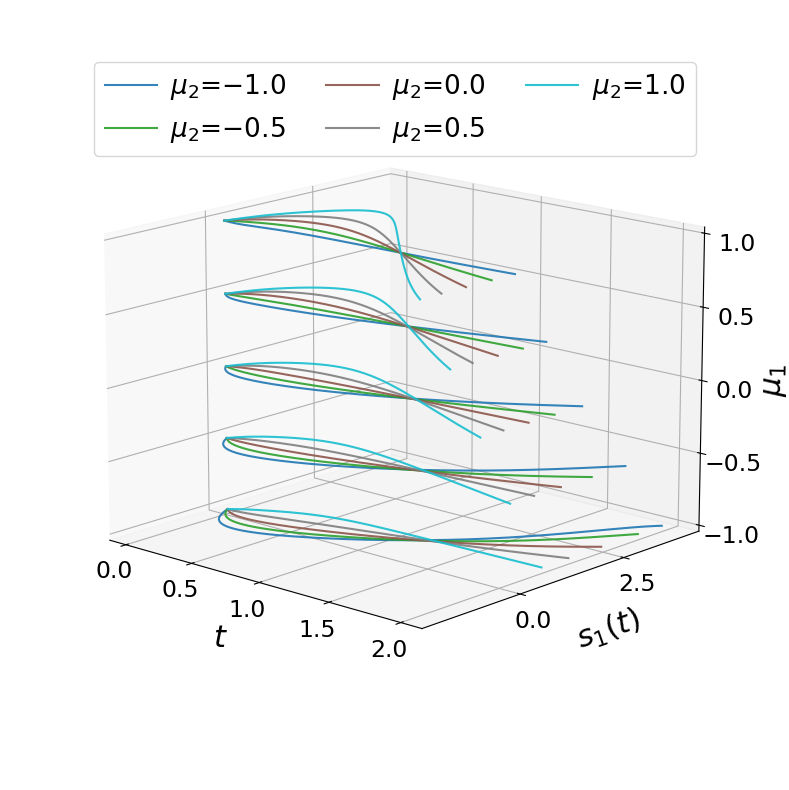

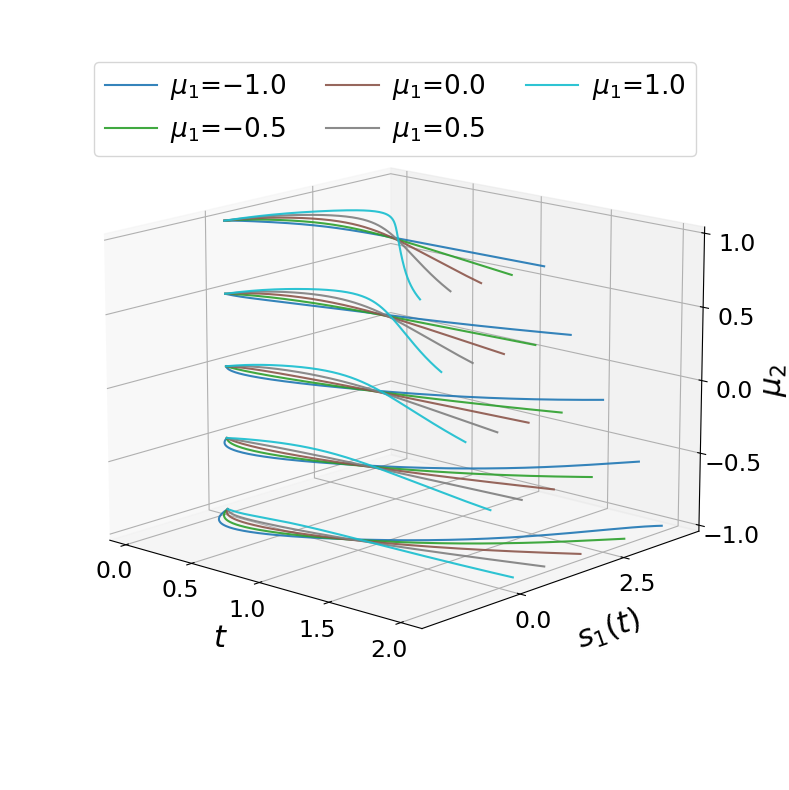

In [26]:
component = 0
plotting.plot_latent_3d_by_mu(HyperParams, component=component, latents=latents, params=params, param_sample=25, mu_varying=0, elev=15, azim =-48)
plotting.plot_latent_3d_by_mu(HyperParams, component=component, latents=latents, params=params, param_sample=25, mu_varying=1, elev=15, azim =-48)